# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


ModuleNotFoundError: No module named 'utstd'

In [2]:
! pip install -i https://test.pypi.org/simple/ my_krml_25548684_at1==0.2.6

Looking in indexes: https://test.pypi.org/simple/



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [4]:
# Open-Meteo Setup
import openmeteo_requests
import requests_cache
from retry_requests import retry

# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries from custom package
from my_krml_25548684_at1.data.sets import *
from my_krml_25548684_at1.plots.numeric import *
from my_krml_25548684_at1.features.num_cat import *
from my_krml_25548684_at1.features.null import *
from my_krml_25548684_at1.models.performance import *

# Import libraries for Creating pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# Import libraries for Data Transformation
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Import libraries for Saving models and pipelines
import joblib
import cloudpickle
from pathlib import Path

## 1. Declaring Constants

In [5]:
# Latitude and Longitude Coordinates for Sydney
LAT, LON = -33.8678, 151.2073

# Dataset URL
DATASET_URL = "https://archive-api.open-meteo.com/v1/archive"

# Start and End Date
START_DATE, END_DATE = "2010-01-01", "2024-12-31"

# Timezone
TIMEZONE = "Australia/Sydney"

---
## A. Project Description


In [ ]:
# <Student to fill this section>
student_name = "Gowtham Kamasamudra Prasanna"
student_id = "25548684."

In [11]:
# Do not modify this code
print("Student-" ,student_name, "\n id is ",student_id)

Student- Gowtham Kamasamudra Prasanna 
 id is  25548684


---
## B. Business Understanding

In [9]:
# <Student to fill this section>
business_use_case_description = """
This project aims to develop a regression-based model that forecasts the expected cumulative precipitation volume (in mm) over the next three days in
Sydney. Unlike simple binary predictions, this approach provides quantitative insights, enabling businesses to plan with precision rather than just 
react to categorical outcomes. Delivering these outputs through an API ensures integration into diverse workflows. Quantitative rainfall predictions 
are particularly valuable for industries where exact water volumes directly impact operations, such as irrigation scheduling in agriculture, risk 
modeling in insurance, hydropower optimization in energy, and event planning. This enhances Open Meteo’s service offering and strengthens its 
competitive edge.
"""

In [10]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [11]:
# <Student to fill this section>
business_objectives = """
Accurate quantitative forecasts allow industries to optimize resource allocation and prevent costly disruptions. For example, farmers can avoid crop 
damage through precise irrigation adjustments, while energy providers can optimize hydropower operations based on predicted inflows. Insurance 
companies benefit from improved risk assessment models, and logistics operators gain foresight into weather-related delays. However, incorrect 
results can have severe consequences: underestimation may lead to unpreparedness for flooding, while overestimation may cause wasted resources 
and unnecessary precautions. The key objective is to ensure forecasts are both reliable and precise, so clients can trust predictions as actionable, 
data-driven tools for strategic and operational planning.
"""

In [12]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [13]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
The regression results will be accessed via predictive APIs, providing cumulative rainfall estimates in a structured and consistent format. Internal 
stakeholders expect models that are scalable, efficient, and easily deployable within Open Meteo’s infrastructure. External stakeholders, such as
enterprise clients, expect smooth integration, low-latency responses, and reliable predictions. Business stakeholders—spanning agriculture, insurance,
logistics, energy, and event management—expect accurate precipitation volumes to drive critical planning decisions. Their operations often hinge 
on precise rainfall estimates, so the model’s reliability directly impacts cost savings, risk management, and efficiency. Ultimately, stakeholders 
expect high accuracy, seamless usability, and forecasts that translate into measurable value.
"""

In [14]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

> For this experiment, I will be pulling hourly weather data directly from the Open-Meteo API. Since the goal is to predict cumulative precipitation volume over a three-day horizon, hourly variables provide the necessary temporal resolution to capture short-term fluctuations and rapid atmospheric changes that drive rainfall intensity.

>After extensive research, I found that quantitative precipitation forecasting relies on a wider set of variables than binary rain prediction. These include:
>
> - Temperature & Moisture Dynamics
> - Cloud Cover & Radiation
> - Wind & Pressure Systems
> - Soil & Evapotranspiration
>
>Together, these hourly predictors create a fine-grained view of atmospheric and surface conditions, enabling more accurate estimation of precipitation volumes.

### C.1   Load Datasets


In [15]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

In [16]:
# Hourly Features

hourly_vars = [
    # Temperature & Derived
    "temperature_2m",  "apparent_temperature", "dew_point_2m", "wet_bulb_temperature_2m",

    # Moisture & Humidity
    "relative_humidity_2m", "vapour_pressure_deficit", "total_column_integrated_water_vapour",

    # Precipitation & Snow
    "precipitation", "snowfall", "snow_depth", "snow_depth_water_equivalent",   # (CERRA only)

    # Clouds & Radiation / Sunshine
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high", "sunshine_duration", "albedo",                       # (CERRA only)

    # Wind
    "wind_speed_10m", "wind_speed_100m", "wind_direction_10m", "wind_direction_100m", "wind_gusts_10m",

    # Pressure & Atmosphere
    "pressure_msl", "surface_pressure", "boundary_layer_height", "weather_code",

    # Soil & Land Surface
    "soil_temperature_0_to_7cm", "soil_temperature_7_to_28cm", "soil_temperature_28_to_100cm", "soil_temperature_100_to_255cm", 
    "soil_moisture_0_to_7cm", "soil_moisture_7_to_28cm", "soil_moisture_28_to_100cm", "soil_moisture_100_to_255cm",

    # Energy & Evapotranspiration
    "et0_fao_evapotranspiration",

    # Temporal / Flags
    "is_day"
]

In [17]:
# Build API request params

params = {
	"latitude": LAT,
	"longitude": LON,
	"hourly": hourly_vars,
	"timezone": "Australia/Sydney",
	"start_date": START_DATE,
	"end_date": END_DATE,
}

In [18]:
# Fetch data from Open-Meteo
responses = openmeteo.weather_api(DATASET_URL, params=params)

In [19]:
# Location data from the response
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

Coordinates: -33.84885787963867°N 151.1955108642578°E
Elevation: 51.0 m asl
Timezone: b'Australia/Sydney'b'GMT+10'
Timezone difference to GMT+0: 36000s


In [20]:
# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_dew_point_2m = hourly.Variables(2).ValuesAsNumpy()
hourly_apparent_temperature = hourly.Variables(3).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(4).ValuesAsNumpy()
hourly_snowfall = hourly.Variables(5).ValuesAsNumpy()
hourly_snow_depth = hourly.Variables(6).ValuesAsNumpy()
hourly_weather_code = hourly.Variables(7).ValuesAsNumpy()
hourly_pressure_msl = hourly.Variables(8).ValuesAsNumpy()
hourly_surface_pressure = hourly.Variables(9).ValuesAsNumpy()
hourly_cloud_cover = hourly.Variables(10).ValuesAsNumpy()
hourly_cloud_cover_low = hourly.Variables(11).ValuesAsNumpy()
hourly_cloud_cover_high = hourly.Variables(12).ValuesAsNumpy()
hourly_cloud_cover_mid = hourly.Variables(13).ValuesAsNumpy()
hourly_et0_fao_evapotranspiration = hourly.Variables(14).ValuesAsNumpy()
hourly_vapour_pressure_deficit = hourly.Variables(15).ValuesAsNumpy()
hourly_wind_direction_10m = hourly.Variables(16).ValuesAsNumpy()
hourly_wind_direction_100m = hourly.Variables(17).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(18).ValuesAsNumpy()
hourly_wind_speed_100m = hourly.Variables(19).ValuesAsNumpy()
hourly_wind_gusts_10m = hourly.Variables(20).ValuesAsNumpy()
hourly_soil_temperature_0_to_7cm = hourly.Variables(21).ValuesAsNumpy()
hourly_soil_temperature_7_to_28cm = hourly.Variables(22).ValuesAsNumpy()
hourly_soil_temperature_28_to_100cm = hourly.Variables(23).ValuesAsNumpy()
hourly_soil_temperature_100_to_255cm = hourly.Variables(24).ValuesAsNumpy()
hourly_soil_moisture_0_to_7cm = hourly.Variables(25).ValuesAsNumpy()
hourly_soil_moisture_7_to_28cm = hourly.Variables(26).ValuesAsNumpy()
hourly_soil_moisture_28_to_100cm = hourly.Variables(27).ValuesAsNumpy()
hourly_soil_moisture_100_to_255cm = hourly.Variables(28).ValuesAsNumpy()
hourly_boundary_layer_height = hourly.Variables(29).ValuesAsNumpy()
hourly_wet_bulb_temperature_2m = hourly.Variables(30).ValuesAsNumpy()
hourly_total_column_integrated_water_vapour = hourly.Variables(31).ValuesAsNumpy()
hourly_is_day = hourly.Variables(32).ValuesAsNumpy()
hourly_sunshine_duration = hourly.Variables(33).ValuesAsNumpy()
hourly_albedo = hourly.Variables(34).ValuesAsNumpy()
hourly_snow_depth_water_equivalent = hourly.Variables(35).ValuesAsNumpy()

hourly_data = {
                "date": pd.date_range(
                                    	start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
                                    	end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
                                    	freq = pd.Timedelta(seconds = hourly.Interval()),
                                    	inclusive = "left"
                                    ).tz_convert("Australia/Sydney")
              }

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["dew_point_2m"] = hourly_dew_point_2m
hourly_data["apparent_temperature"] = hourly_apparent_temperature
hourly_data["precipitation"] = hourly_precipitation
hourly_data["snowfall"] = hourly_snowfall
hourly_data["snow_depth"] = hourly_snow_depth
hourly_data["weather_code"] = hourly_weather_code
hourly_data["pressure_msl"] = hourly_pressure_msl
hourly_data["surface_pressure"] = hourly_surface_pressure
hourly_data["cloud_cover"] = hourly_cloud_cover
hourly_data["cloud_cover_low"] = hourly_cloud_cover_low
hourly_data["cloud_cover_high"] = hourly_cloud_cover_high
hourly_data["cloud_cover_mid"] = hourly_cloud_cover_mid
hourly_data["et0_fao_evapotranspiration"] = hourly_et0_fao_evapotranspiration
hourly_data["vapour_pressure_deficit"] = hourly_vapour_pressure_deficit
hourly_data["wind_direction_10m"] = hourly_wind_direction_10m
hourly_data["wind_direction_100m"] = hourly_wind_direction_100m
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
hourly_data["wind_speed_100m"] = hourly_wind_speed_100m
hourly_data["wind_gusts_10m"] = hourly_wind_gusts_10m
hourly_data["soil_temperature_0_to_7cm"] = hourly_soil_temperature_0_to_7cm
hourly_data["soil_temperature_7_to_28cm"] = hourly_soil_temperature_7_to_28cm
hourly_data["soil_temperature_28_to_100cm"] = hourly_soil_temperature_28_to_100cm
hourly_data["soil_temperature_100_to_255cm"] = hourly_soil_temperature_100_to_255cm
hourly_data["soil_moisture_0_to_7cm"] = hourly_soil_moisture_0_to_7cm
hourly_data["soil_moisture_7_to_28cm"] = hourly_soil_moisture_7_to_28cm
hourly_data["soil_moisture_28_to_100cm"] = hourly_soil_moisture_28_to_100cm
hourly_data["soil_moisture_100_to_255cm"] = hourly_soil_moisture_100_to_255cm
hourly_data["boundary_layer_height"] = hourly_boundary_layer_height
hourly_data["wet_bulb_temperature_2m"] = hourly_wet_bulb_temperature_2m
hourly_data["total_column_integrated_water_vapour"] = hourly_total_column_integrated_water_vapour
hourly_data["is_day"] = hourly_is_day
hourly_data["sunshine_duration"] = hourly_sunshine_duration
hourly_data["albedo"] = hourly_albedo
hourly_data["snow_depth_water_equivalent"] = hourly_snow_depth_water_equivalent

In [21]:
df = pd.DataFrame(data = hourly_data)
df.head()

,date,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,snowfall,snow_depth,weather_code,pressure_msl,...,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm,boundary_layer_height,wet_bulb_temperature_2m,total_column_integrated_water_vapour,is_day,sunshine_duration,albedo,snow_depth_water_equivalent
0,2010-01-01 01:00:00+11:00,21.370499,24.470396,95.496223,20.620499,20.818089,0.114551,39.000000,0.0,0.0,...,21.520500,22.620499,19.320499,21.970501,0.179,0.194,0.093,0.124,0.0,0.0
1,2010-01-01 02:00:00+11:00,21.220501,24.561884,96.081894,20.570499,20.742687,0.098745,38.599998,0.0,0.0,...,21.370499,22.520500,19.320499,21.920502,0.179,0.194,0.093,0.124,0.0,0.0
2,2010-01-01 03:00:00+11:00,21.120499,24.612425,96.375763,20.520500,20.679987,0.090781,38.700001,0.0,0.0,...,21.320499,22.420502,19.320499,21.920502,0.179,0.194,0.093,0.124,0.0,0.0
3,2010-01-01 04:00:00+11:00,21.070499,24.607193,96.672081,20.520500,20.667475,0.083104,39.500000,0.0,0.0,...,21.270500,22.370499,19.320499,21.920502,0.179,0.194,0.093,0.124,0.0,0.0
4,2010-01-01 05:00:00+11:00,21.070499,24.560318,96.672081,20.520500,20.667475,0.083104,40.599998,0.0,0.0,...,21.270500,22.270500,19.320499,21.920502,0.179,0.194,0.093,0.124,0.0,0.0


### C.2 Define Target variable

In [22]:
# Define the target variable
target_name = 'precipitation_sum_3d'

In [23]:
# <Student to fill this section>
target_definition_explanations = """
The target variable precipitation_sum_3d represents the cumulative precipitation (in mm) over the next 72 hours, calculated using a rolling 
window of hourly data. This definition reflects the business need for precise rainfall volumes to inform decisions in sectors like agriculture, 
energy, and insurance, where quantitative estimates are more valuable than binary forecasts.
"""

In [24]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [25]:
# Create the target variable
df[target_name] = (df["precipitation"].rolling(window=72, min_periods=72).sum().shift(-71))

In [26]:
# Drop the feature to prevent data leakage
df.drop(columns = "precipitation", inplace = True)

### C.4 Explore Target variable

In [27]:
# Create a copy of the dataset with the required features for EDA
df_plot = df[['date', "relative_humidity_2m", "temperature_2m", 'precipitation_sum_3d']].copy()

In [28]:
# Extract the target column from the DataFrame using the specified target column name
target = df_plot[target_name]

In [29]:
# Display descriptive statistics
target.describe()

count    131425.000000
mean       1022.124785
std         296.803283
min         321.816355
25%         776.672826
50%        1020.076138
75%        1277.188314
max        1700.266235
Name: precipitation_sum_3d, dtype: float64

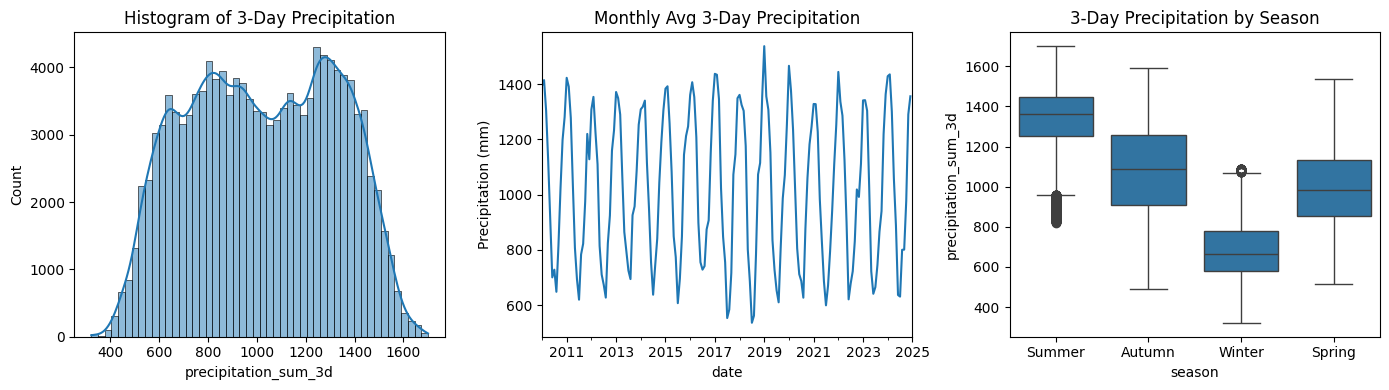

In [30]:
plt.figure(figsize=(14,4))

# Histogram
plt.subplot(1,3,1)
sns.histplot(target.dropna(), bins=50, kde=True)
plt.title("Histogram of 3-Day Precipitation")


# Time Series (Monthly Mean)
plt.subplot(1,3,2)
df_resampled = df_plot.set_index('date')['precipitation_sum_3d'].resample('M').mean()
df_resampled.plot(ax=plt.gca())
plt.title("Monthly Avg 3-Day Precipitation")
plt.ylabel("Precipitation (mm)")

# Boxplot by Season
plt.subplot(1,3,3)
df_plot['month'] = df_plot['date'].dt.month

# Map each month (from the 'month' column) to its corresponding season and create a new 'season' column in the DataFrame
season_map = {
    12:"Summer",1:"Summer",2:"Summer",
    3:"Autumn",4:"Autumn",5:"Autumn",
    6:"Winter",7:"Winter",8:"Winter",
    9:"Spring",10:"Spring",11:"Spring"
}
df_plot['season'] = df_plot['month'].map(season_map)
sns.boxplot(x = "season", y = "precipitation_sum_3d", data = df_plot)
plt.title("3-Day Precipitation by Season")

plt.tight_layout()
plt.show()

In [31]:
# <Student to fill this section>
target_distribution_explanations = """
The histogram shows 3-day precipitation values mostly between 600–1400 mm, centered around 1000–1200 mm, with few extremes. The time series reveals consistent annual
cycles from 2010–2024, with peaks in wetter months and troughs in drier months. Seasonal boxplots show summer has the highest median precipitation (~1350 mm) with wide
spread, winter the lowest (~650 mm) with narrow variability, and autumn/spring intermediate, confirming strong seasonal influence on rainfall amounts.
"""

In [32]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `relative_humidity_2m`

In [33]:
# Assign the feature name 'relative_humidity_2m' to the variable feat_1
feat_1 = "relative_humidity_2m"

In [34]:
# Display descriptive statistics
df_plot[feat_1].describe()

count    131496.000000
mean         16.856443
std           6.530481
min          -2.973838
25%          11.974866
50%          16.887398
75%          21.644304
max          45.181961
Name: relative_humidity_2m, dtype: float64

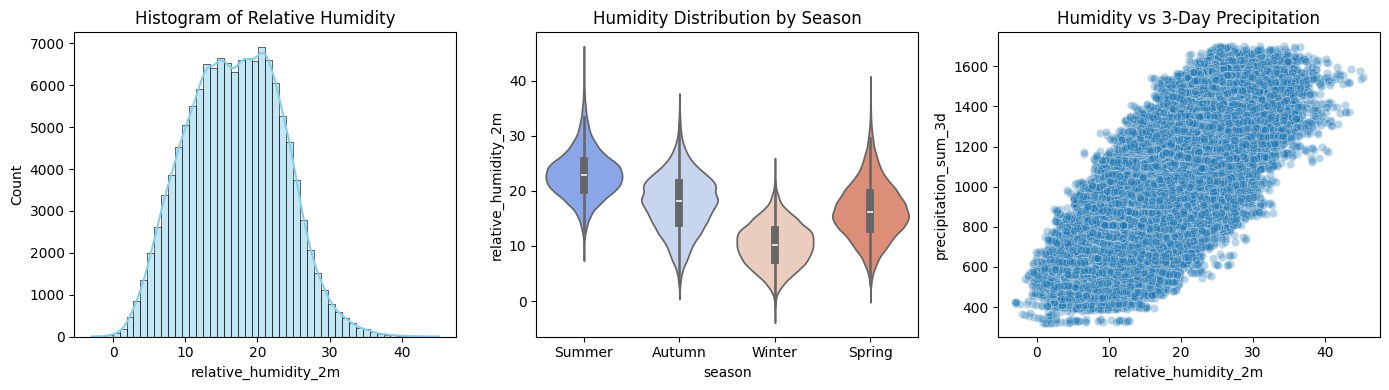

In [35]:
plt.figure(figsize=(14,4))

# Histogram
plt.subplot(1,3,1)
sns.histplot(df_plot[feat_1], bins = 50, kde = True, color = "skyblue")
plt.title("Histogram of Relative Humidity")

# Violin Plot vs Season
plt.subplot(1,3,2)
sns.violinplot(x = "season", y = feat_1, data = df_plot, palette = "coolwarm")
plt.title("Humidity Distribution by Season")

# Scatter vs Target
plt.subplot(1,3,3)
sns.scatterplot(x = feat_1, y = target_name, data = df_plot, alpha = 0.3)
plt.title("Humidity vs 3-Day Precipitation")

plt.tight_layout()
plt.show()

In [36]:
# <Student to fill this section>
feature_1_insights = """
The histogram shows relative humidity values mostly between 10–25, centered around 17, with a roughly normal distribution and few extremes. Violin plots indicate 
higher and more variable humidity in summer and autumn, moderate in spring, and lowest in winter, highlighting strong seasonal influence. The scatter plot reveals 
a clear positive correlation with 3-day precipitation totals, confirming that atmospheric moisture significantly affects rainfall intensity.
"""

In [37]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `temperature_2m`

In [38]:
# Assign the feature name 'temperature_2m' to the variable feat_2
feat_2 = "temperature_2m"

In [39]:
# Display descriptive statistics
df_plot[feat_2].describe()

count    131496.000000
mean         17.532635
std           5.025479
min           0.937500
25%          13.920500
50%          17.687500
75%          21.037500
max          41.837502
Name: temperature_2m, dtype: float64

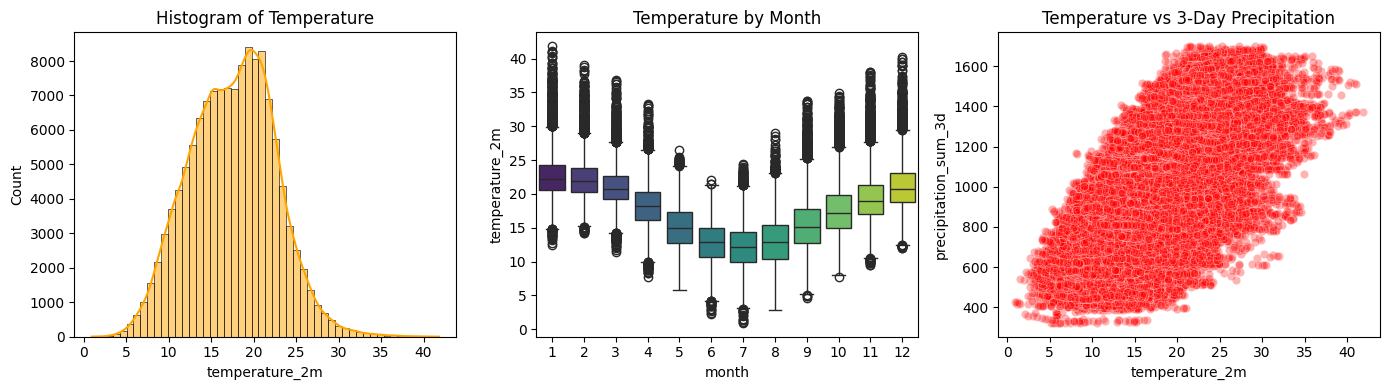

In [40]:
plt.figure(figsize=(14,4))

# Histogram
plt.subplot(1,3,1)
sns.histplot(df_plot[feat_2], bins = 50, kde = True, color = "orange")
plt.title("Histogram of Temperature")

# Boxplot by Month
plt.subplot(1,3,2)
sns.boxplot(x = "month", y = feat_2, data = df_plot, palette = "viridis")
plt.title("Temperature by Month")

# Scatter vs Target
plt.subplot(1,3,3)
sns.scatterplot(x = feat_2, y = target_name, data = df_plot, alpha = 0.3, color = "red")
plt.title("Temperature vs 3-Day Precipitation")

plt.tight_layout()
plt.show()

In [41]:
# <Student to fill this section>
feature_2_insights = """
The histogram shows temperature values mostly between 14–22°C, centered around 17.5°C, with few extreme readings, indicating generally moderate conditions. Monthly 
boxplots reveal peaks in summer (≥30°C) and lows in winter (10–12°C), reflecting a strong cyclical pattern. The scatter plot shows a positive association with 
precipitation, where rainfall is highest between 15–30°C, suggesting temperature influences rainfall intensity within a moderate range.
"""

In [42]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

---
## D. Data Preparation for Modeling

In [43]:
# Create the features 'X' and target variable 'y' from the custom package
X, y = pop_target(df = df, target_col = target_name)

In [44]:
# Splitting the dataset into training, validation and test sets from the custom package
X_train_val, y_train_val, X_test, y_test = data_splitting_based_on_time(X = X, y = y, date_col = 'date', test_size = 0.2, random_state = 42)

In [45]:
# Splitting the train_val dataset into training and validation sets from the custom package
X_train, y_train, X_val, y_val = data_splitting_based_on_time(X = X_train_val, y = y_train_val, date_col = 'date', test_size = 0.2, random_state = 42)

In [46]:
# Create the training, validation and test dataframe
train_df = pd.concat([X_train, y_train], axis = 1)
val_df = pd.concat([X_val, y_val], axis = 1)
test_df = pd.concat([X_test, y_test], axis = 1)

In [47]:
# Save all datasets
try:
  train_df.to_csv("../../data/raw/precipitation_fall/train.csv", index=False)
  val_df.to_csv("../../data/raw/precipitation_fall/val.csv", index=False)
  test_df.to_csv("../../data/raw/precipitation_fall/test.csv", index=False)
except Exception as e:
  print(e)

In [48]:
# # In case, you want to start from imported datasets, then uncomment this block

# # Import all datasets
# train_df = pd.read_csv("../../data/raw/precipitation_fall/train.csv")
# val_df = pd.read_csv("../../data/raw/precipitation_fall/val.csv")
# test_df = pd.read_csv("../../data/raw/precipitation_fall/test.csv")

# # Ensure date is of type datetime
# train_df['date'] = pd.to_datetime(train_df['date'], utc=True)
# val_df['date'] = pd.to_datetime(val_df['date'], utc=True)
# test_df['date'] = pd.to_datetime(test_df['date'], utc=True)

# # Define target name
# target_name = "precipitation_sum_3d"

# # Create features and target for each dataset

# X_train, y_train = pop_target(df = train_df, target_col = target_name)
# X_val, y_val = pop_target(df = val_df, target_col = target_name)
# X_test, y_test = pop_target(df = test_df, target_col = target_name)

---
## E. Feature Selection

### E.1 Approach `Removal of features having > 50% null values`

In [49]:
# Get all the features having more than 50% null values in the training set from the custom package function
null_features_more_than_50 = return_null_features_series(df = train_df, series = train_df.isnull().sum(), target_col = target_name, threshold = 0.5, symbol = '>')
null_features_more_than_50

['cloud_cover', 'wind_direction_10m']

In [50]:
# <Student to fill this section>
feature_selection_1_insights = """
Features with excessive missing values add noise and reduce reliability. By discarding such variables, we maintained a consistent feature set 
without heavy imputation. This preserved data integrity and prevented bias from sparsely observed predictors, ensuring a more reliable model
foundation.
"""

In [51]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### E.2 Approach `Removal of constant features`

In [52]:
# Check for constant features
constant_features = [col for col in train_df.columns if train_df[col].nunique(dropna=True) == 1]
print(constant_features)

['pressure_msl', 'surface_pressure']


In [53]:
# <Student to fill this section>
feature_selection_2_insights = """
Constant features lack variability and provide no discriminatory power for prediction. Removing them simplified the dataset and eliminated 
unnecessary dimensions. This streamlined the feature space, improving model efficiency without sacrificing performance or interpretability.
"""

In [54]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### E.3 Approach `Removal of correlated features`

In [55]:
# Compute correlation matrix (numeric only)
corr_matrix = X_train.corr(numeric_only=True)

In [56]:
# Upper triangle mask to avoid duplicates
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [57]:
# Features with correlation > 0.85
highly_correlated_features = [column for column in upper.columns if any(upper[column].abs() > 0.85)]
highly_correlated_features

['relative_humidity_2m',
 'wind_speed_10m',
 'wind_gusts_10m',
 'soil_temperature_0_to_7cm',
 'soil_temperature_28_to_100cm',
 'soil_moisture_7_to_28cm',
 'soil_moisture_28_to_100cm',
 'boundary_layer_height',
 'total_column_integrated_water_vapour']

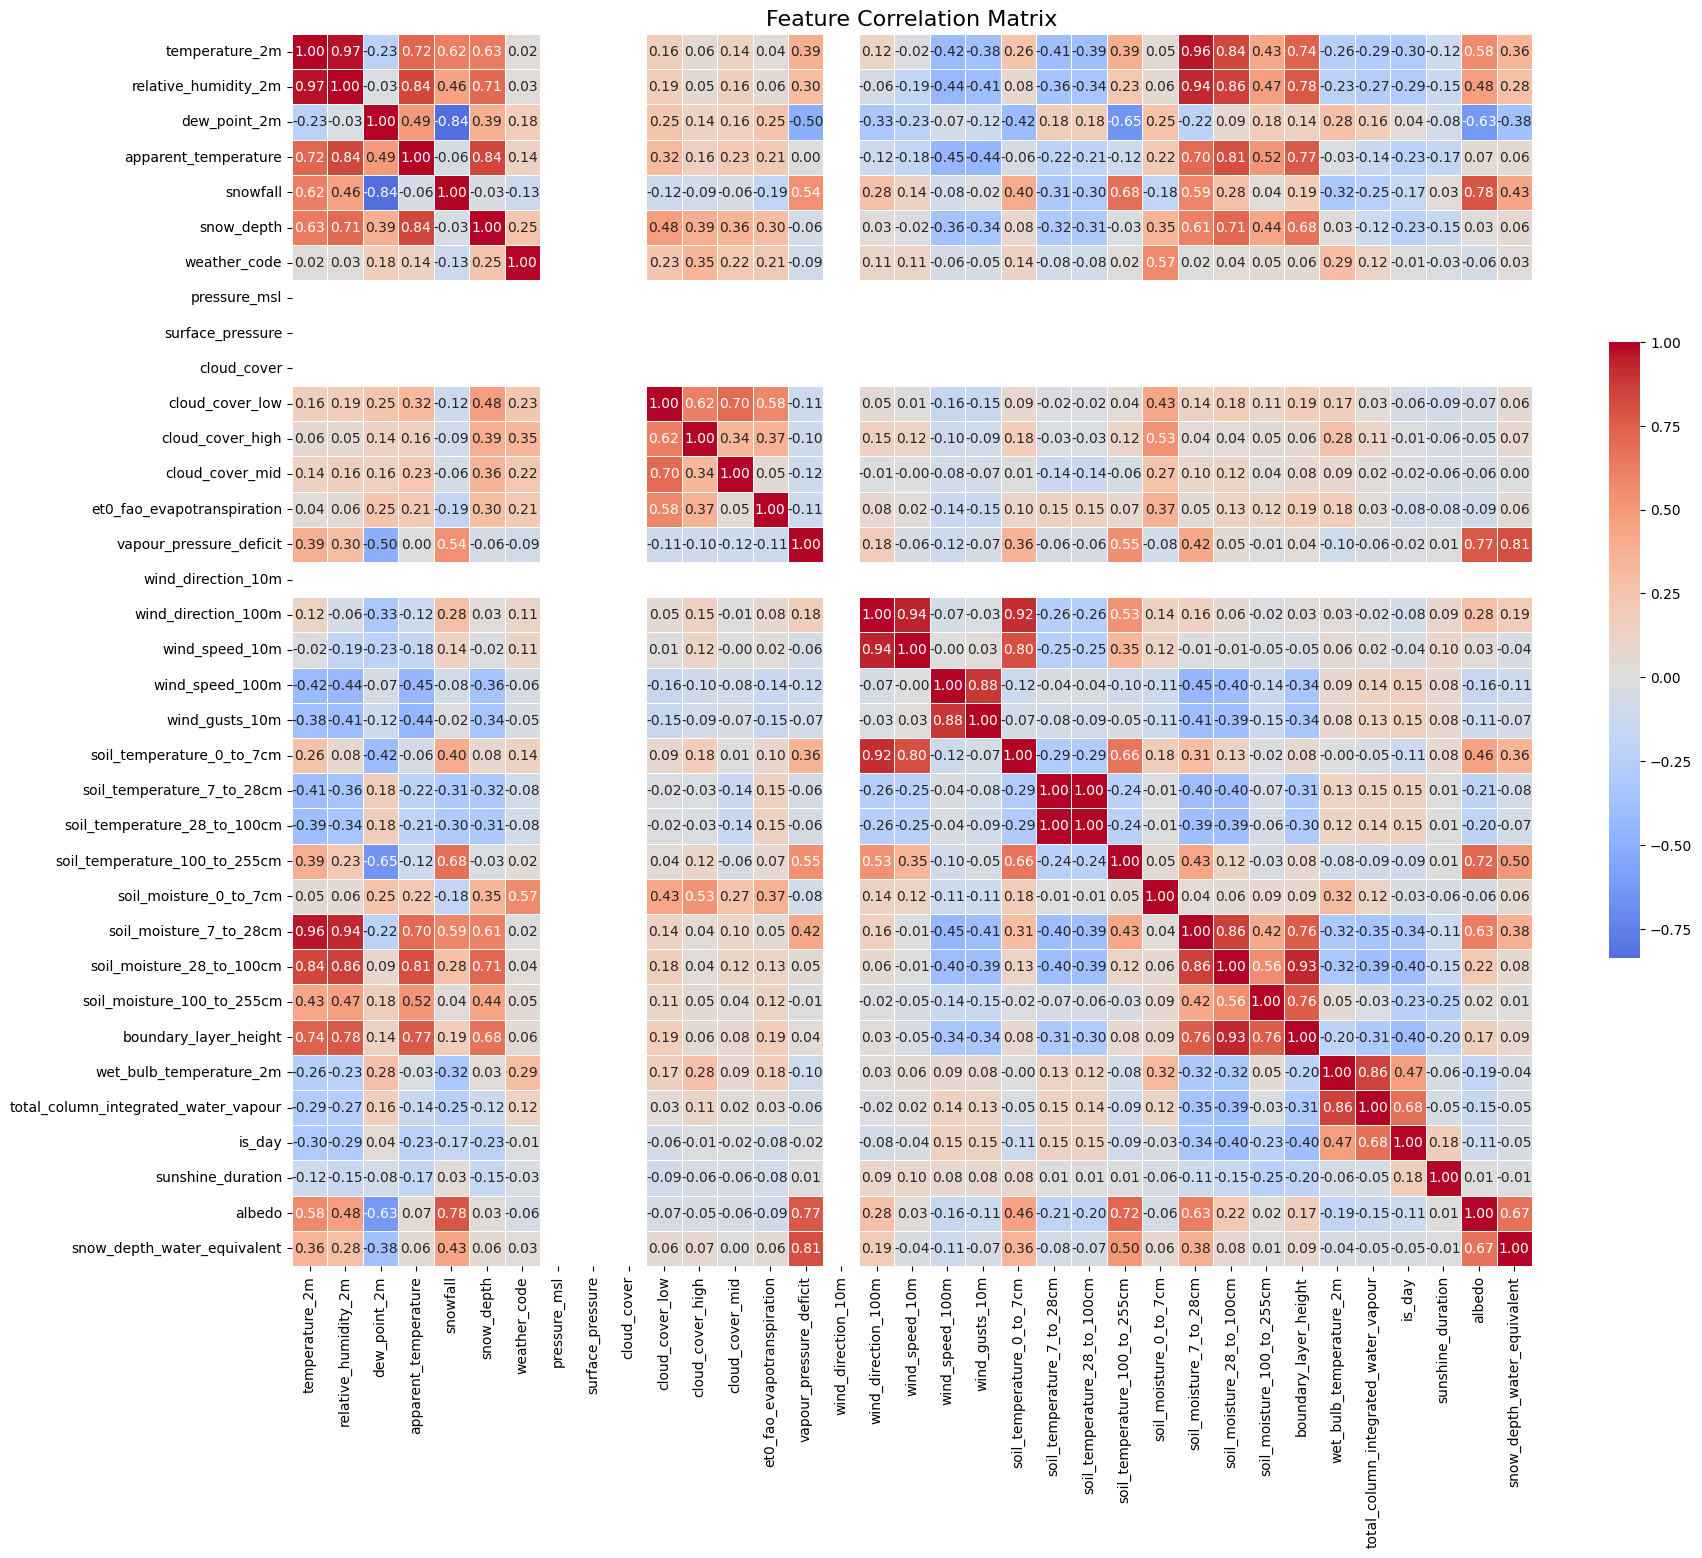

In [58]:
# Plot the correlation matrix
plot_correlation_matrix(corr_matrix, figsize = (20, 16), cmap = "coolwarm", title = "Feature Correlation Matrix")

In [59]:
# <Student to fill this section>
feature_selection_3_insights = """
Strongly correlated predictors can lead to multicollinearity, reducing model robustness and interpretability. By discarding one of each 
correlated pair, only independent predictors were retained. This enhanced model generalization while preserving essential information for
precipitation forecasting.
"""

In [60]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_3_insights', value=feature_selection_3_insights)

## E.4 Final Selection of Features

In [61]:
# Create a list consisting of all the features to remove
features_to_remove = null_features_more_than_50 + constant_features + highly_correlated_features
features_to_remove

['cloud_cover',
 'wind_direction_10m',
 'pressure_msl',
 'surface_pressure',
 'relative_humidity_2m',
 'wind_speed_10m',
 'wind_gusts_10m',
 'soil_temperature_0_to_7cm',
 'soil_temperature_28_to_100cm',
 'soil_moisture_7_to_28cm',
 'soil_moisture_28_to_100cm',
 'boundary_layer_height',
 'total_column_integrated_water_vapour']

In [62]:
# Creating the final features list 

features_list = [col for col in X_train.columns.tolist() if col not in features_to_remove]
features_list

['date',
 'temperature_2m',
 'dew_point_2m',
 'apparent_temperature',
 'snowfall',
 'snow_depth',
 'weather_code',
 'cloud_cover_low',
 'cloud_cover_high',
 'cloud_cover_mid',
 'et0_fao_evapotranspiration',
 'vapour_pressure_deficit',
 'wind_direction_100m',
 'wind_speed_100m',
 'soil_temperature_7_to_28cm',
 'soil_temperature_100_to_255cm',
 'soil_moisture_0_to_7cm',
 'soil_moisture_100_to_255cm',
 'wet_bulb_temperature_2m',
 'is_day',
 'sunshine_duration',
 'albedo',
 'snow_depth_water_equivalent']

In [63]:
# Add the target variable to the list of selected features
features_list.append(target_name)

In [64]:
# <Student to fill this section>
feature_selection_explanations = """
The selected features cover cloud cover, wind speed, gusts, direction, surface and soil conditions, boundary layer height, pressure, and 
atmospheric water vapour. These variables collectively reflect interactions between atmospheric dynamics and surface processes, making them 
highly relevant for estimating cumulative precipitation over three days.
"""

In [65]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## F. Data Cleaning

In [66]:
# Creating a new dataframes for the purposes of data cleaning
train_clean = train_df[features_list]
val_clean = val_df[features_list]
test_clean = test_df[features_list]

### F.1 Data Cleaning `Handling Null Values`

In [67]:
# Checking for null values in the training dataset
train_clean.isnull().sum()

date                             0
temperature_2m                   0
dew_point_2m                     0
apparent_temperature             0
snowfall                         0
snow_depth                       0
weather_code                     0
cloud_cover_low                  0
cloud_cover_high                 0
cloud_cover_mid                  0
et0_fao_evapotranspiration       0
vapour_pressure_deficit          0
wind_direction_100m              0
wind_speed_100m                  0
soil_temperature_7_to_28cm       0
soil_temperature_100_to_255cm    0
soil_moisture_0_to_7cm           0
soil_moisture_100_to_255cm       0
wet_bulb_temperature_2m          0
is_day                           0
sunshine_duration                0
albedo                           0
snow_depth_water_equivalent      0
precipitation_sum_3d             0
dtype: int64

In [68]:
# Checking for null values in the validation dataset
val_clean.isnull().sum()

date                             0
temperature_2m                   0
dew_point_2m                     0
apparent_temperature             0
snowfall                         0
snow_depth                       0
weather_code                     0
cloud_cover_low                  0
cloud_cover_high                 0
cloud_cover_mid                  0
et0_fao_evapotranspiration       0
vapour_pressure_deficit          0
wind_direction_100m              0
wind_speed_100m                  0
soil_temperature_7_to_28cm       0
soil_temperature_100_to_255cm    0
soil_moisture_0_to_7cm           0
soil_moisture_100_to_255cm       0
wet_bulb_temperature_2m          0
is_day                           0
sunshine_duration                0
albedo                           0
snow_depth_water_equivalent      0
precipitation_sum_3d             0
dtype: int64

In [69]:
# Checking for null values in the test dataset
test_clean.isnull().sum()

date                                0
temperature_2m                      0
dew_point_2m                        0
apparent_temperature                0
snowfall                            0
snow_depth                       4368
weather_code                        0
cloud_cover_low                     0
cloud_cover_high                    0
cloud_cover_mid                     0
et0_fao_evapotranspiration          0
vapour_pressure_deficit             0
wind_direction_100m                 0
wind_speed_100m                     0
soil_temperature_7_to_28cm          0
soil_temperature_100_to_255cm    4368
soil_moisture_0_to_7cm              0
soil_moisture_100_to_255cm          0
wet_bulb_temperature_2m             0
is_day                              0
sunshine_duration                   0
albedo                              0
snow_depth_water_equivalent         0
precipitation_sum_3d               71
dtype: int64

In [70]:
# Drop all the instances for which the target variable is null
test_clean.dropna(subset=[target_name], inplace=True)

In [71]:
# Get all the features having null values in the test set from the custom package function
null_features_test = return_null_features_df(df = test_clean, target_col = target_name, threshold = 0, symbol = '>')
null_features_test

['snow_depth', 'soil_temperature_100_to_255cm']

In [72]:
# Features list to impute
impute_feat = [col for col in train_clean.columns if col not in ["date", target_name]]
impute_feat

['temperature_2m',
 'dew_point_2m',
 'apparent_temperature',
 'snowfall',
 'snow_depth',
 'weather_code',
 'cloud_cover_low',
 'cloud_cover_high',
 'cloud_cover_mid',
 'et0_fao_evapotranspiration',
 'vapour_pressure_deficit',
 'wind_direction_100m',
 'wind_speed_100m',
 'soil_temperature_7_to_28cm',
 'soil_temperature_100_to_255cm',
 'soil_moisture_0_to_7cm',
 'soil_moisture_100_to_255cm',
 'wet_bulb_temperature_2m',
 'is_day',
 'sunshine_duration',
 'albedo',
 'snow_depth_water_equivalent']

In [73]:
# Create a column transformer to handle null values

class NumericImputerWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, features):
        self.features = features
        self.imputer = SimpleImputer(strategy="median")
        
    def fit(self, X, y=None):
        self.imputer.fit(X[self.features])
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        X_copy[self.features] = self.imputer.transform(X_copy[self.features])
        return X_copy

In [74]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Handling null values ensures the model receives complete and consistent data, preventing errors during training and improving prediction 
reliability. Dropping or imputing missing entries maintains data integrity, reduces bias, and allows the algorithms to learn meaningful 
without distortions from incomplete records.
"""

In [75]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### F.2 Data Cleaning `Handling Duplicate Values`

In [76]:
# Check the number of duplicate values in the training set
train_clean.duplicated().sum()

np.int64(0)

In [77]:
# Check the number of duplicate values in the validation set
val_clean.duplicated().sum()

np.int64(0)

In [78]:
# Check the number of duplicate values in the test set
test_clean.duplicated().sum()

np.int64(0)

In [79]:
# Create a custom-transformer to handle duplicates

class DuplicateHandler(BaseEstimator, TransformerMixin):
    # To determine whether the index should be reset after dropping duplicates
    def __init__(self, reset_index=True):
        self.reset_index = reset_index

    # Created solely to comply with scikit-learn's API, as removing duplicates doesn't require fitting or learning from the data.
    def fit(self, X, y=None):
        return self
    
    # Remove the duplicates from the dataframe and optionally reset the index
    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        X_clean = X.drop_duplicates()
        if self.reset_index:
            X_clean = X_clean.reset_index(drop=True)
        return X_clean

In [80]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Removing duplicate records prevents the model from being biased toward repeated observations, which could otherwise skew feature importance and 
evaluation metrics. Ensuring each observation is unique improves generalization, enhances training stability, and produces more trustworthy and 
representative predictions for real-world applications.
"""

In [81]:
# Do not modify this code
print_tile(size = "h3", key = 'data_cleaning_2_explanations', value = data_cleaning_2_explanations)

### F.3 Data Cleaning `Handling Outlier Values`

In [82]:
# Identify the numeric and categorical features in the dataset from the custom package
numerical_features, categorical_features = return_numerical_categorical_features(df = train_clean, target_col = target_name)

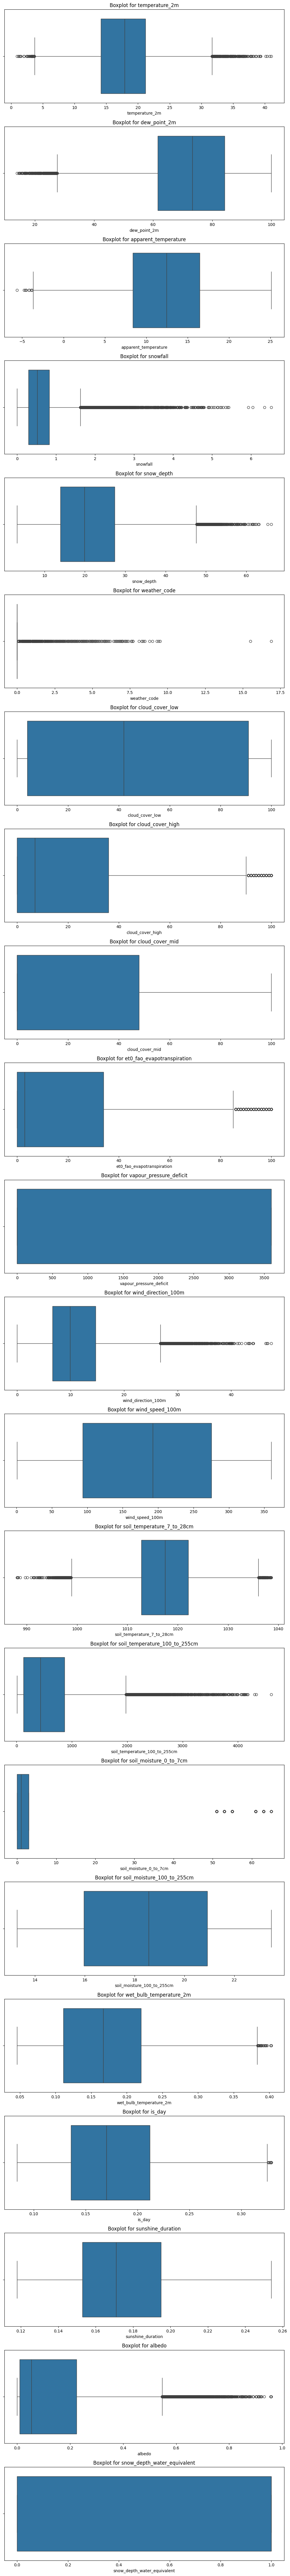

In [83]:
# Plotting the box plot for every numerical feature to identify outliers

plot_boxplots(data = train_clean, columns = numerical_features, figsize=(10, 5), per_col_height=4)

In [84]:
# Create a list of the outlier features
outlier_features = [
    "temperature_2m",
    "dew_point_2m",
    "snowfall",
    "snow_depth",
    "wind_direction_100m",
    "wind_speed_100m",
    "soil_temperature_7_to_28cm",
    "soil_temperature_100_to_255cm",
    "soil_moisture_0_to_7cm",
    "wet_bulb_temperature_2m",
    "albedo"
]

In [85]:
# Create a custom-style transformer to handle outliers

class OutlierHandler(BaseEstimator, TransformerMixin):

    # To initialise with optional feature list and IQR factor for outlier detection
    def __init__(self, features=None, factor=3.0):
        self.features = features
        self.factor = factor
        self.bounds_ = {}

    # Compute IQR-based lower and upper bounds for each specified feature
    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        feats = self.features if self.features is not None else X_df.columns

        for feat in feats:
            q1 = X_df[feat].quantile(0.25)
            q3 = X_df[feat].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - self.factor * iqr
            upper = q3 + self.factor * iqr
            self.bounds_[feat] = (lower, upper)
        return self

    # Clip values outside the IQR bounds to reduce outlier impact
    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        for feat, (lower, upper) in self.bounds_.items():
            X_df[feat] = np.clip(X_df[feat], lower, upper)
        return X_df

In [86]:
# <Student to fill this section>
data_cleaning_3_explanations = """
Winsorizing outliers reduces the impact of extreme values that can disproportionately influence model parameters. This step stabilizes 
training, mitigates overfitting risks, and ensures predictions reflect typical conditions rather than rare, extreme cases, improving 
overall robustness and reliability of both classification and regression models.
"""

In [87]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

### F.4 Data Cleaning Pipeline

In [88]:
# Create a pipeline for data cleaning
cleaning_pipeline = Pipeline(steps=[
    ("imputer", NumericImputerWrapper(impute_feat)),
    ("remove_duplicates", DuplicateHandler(reset_index=True)),
    ("outlier_handler", OutlierHandler(features=outlier_features, factor=3.0))
])

In [89]:
print(cleaning_pipeline)

Pipeline(steps=[('imputer',
                 NumericImputerWrapper(features=['temperature_2m',
                                                 'dew_point_2m',
                                                 'apparent_temperature',
                                                 'snowfall', 'snow_depth',
                                                 'weather_code',
                                                 'cloud_cover_low',
                                                 'cloud_cover_high',
                                                 'cloud_cover_mid',
                                                 'et0_fao_evapotranspiration',
                                                 'vapour_pressure_deficit',
                                                 'wind_direction_100m',
                                                 'wind_speed_100m',
                                                 'soil_temperature_7_to_28cm',
                                                

In [90]:
# Fit and transform the training and validation set using the pipeline
train_clean = cleaning_pipeline.fit_transform(train_clean)
val_clean = cleaning_pipeline.transform(val_clean)

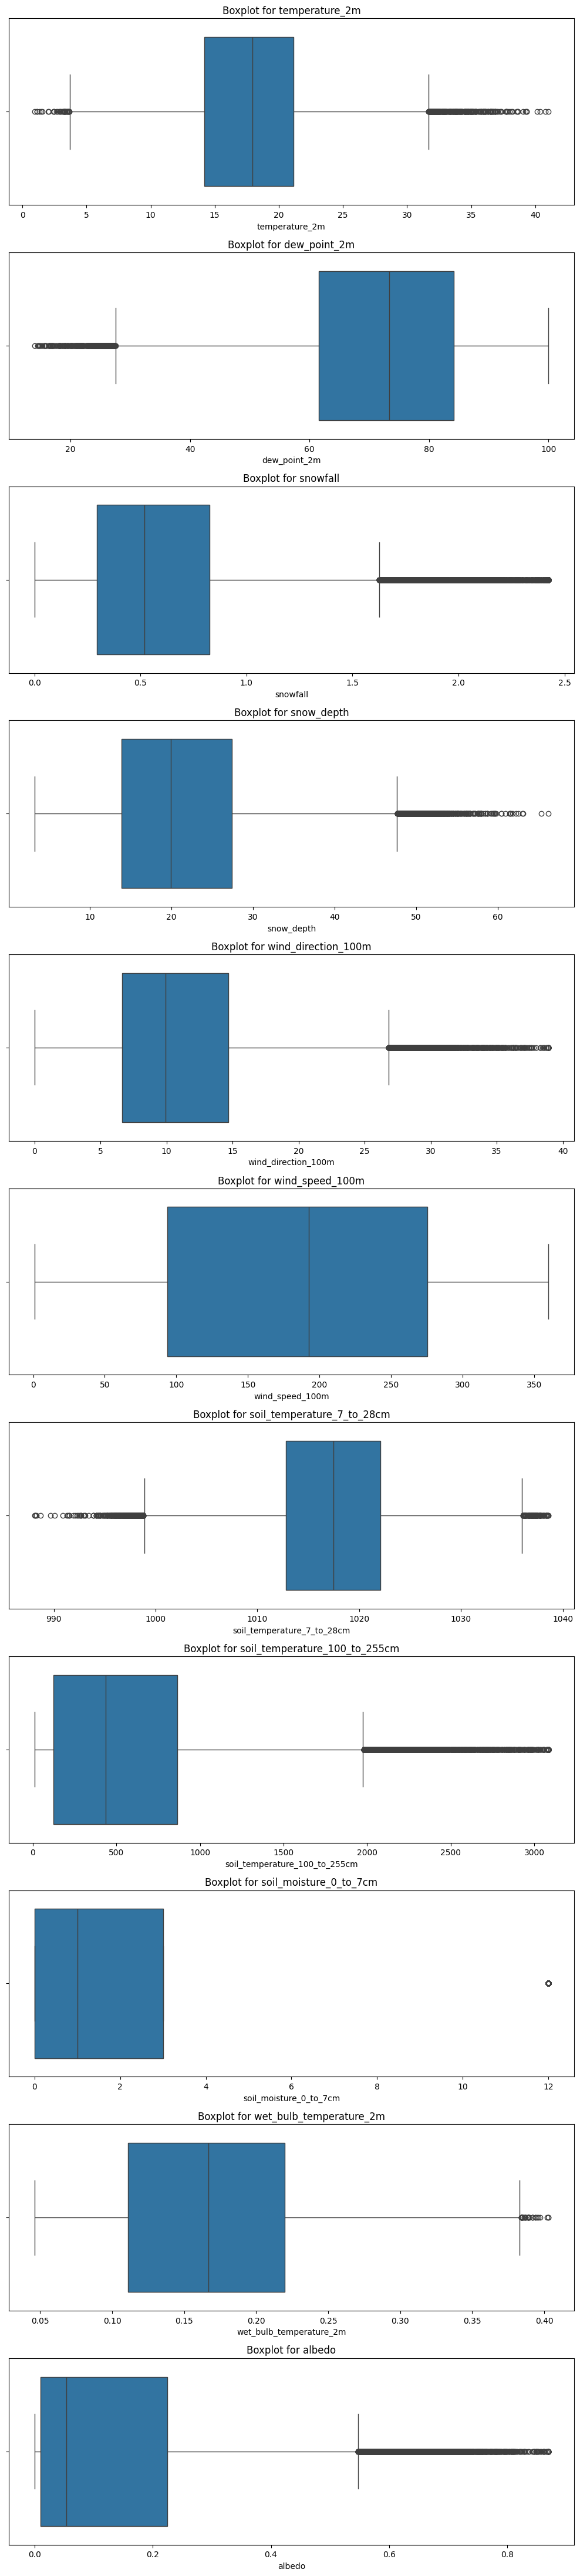

In [91]:
# Plot the outlier features after cleaning
plot_boxplots(data = train_clean, columns = outlier_features, figsize=(10, 5), per_col_height=4)

---
## G. Feature Engineering

In [92]:
# Create copies of the train, validation and test sets
train_eng = train_clean.copy()
val_eng = val_clean.copy()

### G.1 New Feature `Temperature–Dew Point Spread`


In [93]:
# Create a custom column - style transformer pipeline instance for calculating temperature-dew spread

class TempDewSpreadEstimator(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None): 
        return self

    # Create a new feature 'spread' as the difference between temperature and dew point
    def transform(self, X):
        X = X.copy()
        X['spread'] = X['temperature_2m'] - X['dew_point_2m']
        X.drop(columns = ['temperature_2m', 'dew_point_2m'], inplace = True)
        return X

In [94]:
# <Student to fill this section>
feature_engineering_1_explanations = """
The difference between temperature and dew point indicates atmospheric moisture saturation and potential condensation. Including this 
feature enables the model to better quantify precipitation amounts by linking thermal and moisture conditions to rainfall accumulation.
"""

In [95]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### G.2 New Feature `Hourly and Monthly Indicator`




In [96]:
# Create a custom column - style transformer pipeline instance for capturing hourly and monthly features

class DateFeatureExtractor(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None): 
        return self

    # Create new features 'month' and 'season' from the 'date'
    def transform(self, X):
        X = X.copy()

        # Convert 'date' column to datetime if not already
        if not pd.api.types.is_datetime64_any_dtype(X["date"]):
            X["date"] = pd.to_datetime(X["date"], errors="coerce")

        # Extract hour and month from date
        X["hour"] = X["date"].dt.hour
        X["month"] = X["date"].dt.month
        
        X.drop(columns = "date", inplace = True)
        return X


In [97]:
# <Student to fill this section>
feature_engineering_2_explanations = """
Capturing both hour and month allows the model to learn diurnal and seasonal trends in precipitation. Temporal features improve 
prediction accuracy by reflecting typical rainfall patterns within specific hours and months, essential for short-term accumulation forecasts.
"""

In [98]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### G.3 New Feature `Day Length Proxy (Sunshine Ratio)`

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [99]:
# Create a custom column - style transformer pipeline instance for calculating the sunshine ratio

class DayLengthProxyEstimator(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None): 
        return self

    # Create a new feature sunshine ratio
    def transform(self, X):
        X = X.copy()
        X['sunshine_ratio'] = X["sunshine_duration"] / (24 * 3600)
        X.drop(columns = ["sunshine_duration"], inplace = True)
        return X

In [100]:
# <Student to fill this section>
feature_engineering_3_explanations = """
The ratio of sunshine duration to total day length provides a normalized measure of solar exposure, indirectly capturing cloudiness and 
evaporation effects. This feature helps the model account for daytime energy inputs influencing precipitation accumulation over the following 
three days.
"""

In [101]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

### G.4 Feature Engineering Pipeline

In [102]:
# Create a pipeline for feature engineering

eng_pipeline = Pipeline([
    ("temp_dew_spread", TempDewSpreadEstimator()),
    ("date_features", DateFeatureExtractor()),
    ("sunshine_ratio", DayLengthProxyEstimator()),
])

In [103]:
print(eng_pipeline)

Pipeline(steps=[('temp_dew_spread', TempDewSpreadEstimator()),
                ('date_features', DateFeatureExtractor()),
                ('sunshine_ratio', DayLengthProxyEstimator())])


In [104]:
# Fit and transform the training and validation set using the pipeline
train_eng = eng_pipeline.fit_transform(train_clean)
val_eng   = eng_pipeline.transform(val_clean)

---
## H. Data Preparation for Modeling

### H.1 Split Datasets

In [105]:
# Dataset splitting using function from custom package
X_train, y_train = pop_target(train_eng, target_name)
X_val, y_val = pop_target(val_eng, target_name)

In [106]:
# <Student to fill this section>
data_splitting_explanations = """
For this dataset, a time-based split is ideal, using earlier years for training and the most recent data (2025) for testing. This approach 
preserves temporal order, prevents data leakage, and ensures the model is evaluated on future, unseen conditions, reflecting real-world 
forecasting scenarios accurately.
"""

In [107]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### H.2 Data Transformation `Cyclic Encoding of hour`

In [108]:
# Create a custom column - style transformer pipeline instance which performs cyclic encoding for 'hour'

class HourCyclicEncoder(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None): 
        return self
        
    def transform(self, X):
        X = X.copy()
        X['hour_sin'] = np.sin(2 * np.pi * X['hour']/12)
        X['hour_cos'] = np.cos(2 * np.pi * X['hour']/12)
        X = X.drop(columns=['hour'])
        return X

In [109]:
# <Student to fill this section>
data_transformation_1_explanations = """
Converts the cyclical hour feature into sine and cosine components, preserving the circular relationship (e.g., 23 → 0). This prevents 
misleading linear interpretations and improves model understanding of temporal patterns.
"""

In [110]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### H.3 Data Transformation `Cyclic Encoding of 'month'`

In [111]:
# Create a custom column - style transformer pipeline instance which performs cyclic encoding for 'months'

class MonthCyclicEncoder(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None): 
        return self
        
    def transform(self, X):
        X = X.copy()
        X['month_sin'] = np.sin(2 * np.pi * X['month']/12)
        X['month_cos'] = np.cos(2 * np.pi * X['month']/12)
        X = X.drop(columns=['month'])
        return X

In [112]:
# <Student to fill this section>
data_transformation_2_explanations = """
Similar to hour, encoding months cyclically captures seasonal trends without introducing artificial discontinuities between December and January, 
enhancing the model’s ability to learn temporal effects.
"""

In [113]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### H.4 Data Transformation `Standarisation`

In [114]:
# Create a custom column - style transformer pipeline instance which performs standarisation on numerical features

class NumericStandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self, exclude_suffixes=['_sin', '_cos']):
        self.exclude_suffixes = exclude_suffixes
        self.scaler = StandardScaler()
        self.numeric_features = None

    def fit(self, X, y=None):
        self.numeric_features = [c for c in X.columns if not any(c.endswith(suf) for suf in self.exclude_suffixes)]
        self.scaler.fit(X[self.numeric_features])
        return self

    def transform(self, X):
        X = X.copy()
        X[self.numeric_features] = self.scaler.transform(X[self.numeric_features])
        return X

In [115]:
# <Student to fill this section>
data_transformation_3_explanations = """
Scales numeric features to a common range, reducing bias from variables with large magnitudes. This stabilises gradient-based algorithms 
and improves convergence, ensuring all features contribute proportionally to model training.
"""

In [116]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

### H.5 Data Transformation Pipeline

In [117]:
# Create a pipeline for data transformation

data_transform_pipeline = Pipeline([
    ('cyclic_hour', HourCyclicEncoder()),
    ('cyclic_month', MonthCyclicEncoder()),
    ('scaler', NumericStandardScaler())
])

In [118]:
print(data_transform_pipeline)

Pipeline(steps=[('cyclic_hour', HourCyclicEncoder()),
                ('cyclic_month', MonthCyclicEncoder()),
                ('scaler', NumericStandardScaler())])


In [119]:
# Fit and transform the training and validation set using the pipeline

X_train = data_transform_pipeline.fit_transform(X_train)
X_val   = data_transform_pipeline.transform(X_val)

---
## I. Save Datasets

> Do not change this code

In [120]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv("../../data/processed/precipitation_fall/X_train.csv", index=False)
  y_train.to_csv("../../data/processed/precipitation_fall/y_train.csv", index=False)

  X_val.to_csv("../../data/processed/precipitation_fall/X_val.csv", index=False)
  y_val.to_csv("../../data/processed/precipitation_fall/y_val.csv", index=False)
except Exception as e:
  print(e)

---
## J. Selection of Performance Metrics

> RMSE and R² were selected to quantify prediction errors and explained variance, respectively. RMSE penalises large deviations in precipitation 
estimates, while R² indicates how well the model captures overall trends. Together, they provide a robust assessment of regression performance, 
guiding improvements for operationally meaningful forecasts.


In [121]:
# <Student to fill this section>
from sklearn.metrics import mean_squared_error, r2_score

In [122]:
# <Student to fill this section>
performance_metrics_explanations = """
RMSE and R² were selected to quantify prediction errors and explained variance, respectively. RMSE penalises large deviations in precipitation 
estimates, while R² indicates how well the model captures overall trends. Together, they provide a robust assessment of regression performance, 
guiding improvements for operationally meaningful forecasts.
"""

In [123]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## K. Train Machine Learning Model

### K.1 Import Algorithm

> Linear Regression offers a transparent model for predicting precipitation volumes, assuming linear relationships, whereas Random Forest captures
non-linear dependencies and interactions. Using both helps identify whether simple trends suffice or complex patterns improve accuracy, ensuring 
reliable quantitative precipitation forecasts for operational planning.


In [124]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, GridSearchCV

In [125]:
# Dummy Regressor (baseline)
dummy = DummyRegressor(strategy='median')
dummy.fit(X_train, y_train)
y_pred_val = dummy.predict(X_val)

print("Validation RMSE of baseline model:", np.sqrt(mean_squared_error(y_val, y_pred_val)))
print("Validation R-squared score of baseline model:", r2_score(y_val, y_pred_val))

Validation RMSE of baseline model: 288.18626577218055
Validation R-squared score of baseline model: -0.016059591580964927


In [126]:
# <Student to fill this section>
algorithm_selection_explanations = """
Linear Regression offers a transparent model for predicting precipitation volumes, assuming linear relationships, whereas Random Forest captures
non-linear dependencies and interactions. Using both helps identify whether simple trends suffice or complex patterns improve accuracy, ensuring 
reliable quantitative precipitation forecasts for operational planning.
"""

In [127]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### K.2 Set Hyperparameters

> Tuning fit_intercept in Linear Regression ensures proper bias adjustment for accurate precipitation estimates. For Random Forest, parameters 
such as n_estimators, max_depth, and max_features control tree growth, ensemble diversity, and feature sampling, improving prediction accuracy 
while mitigating overfitting on complex, hourly precipitation patterns.


In [128]:
# Declare the hyper-parameters that will be used by Linear Regression
    
param_grid_lr = {
        "fit_intercept": [True, False]
    }

In [129]:
# Declare the hyper-parameters that will be used by Random Forest

param_grid_rf = {
    "n_estimators": [100, 200, 350, 500],
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [130]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
Tuning fit_intercept in Linear Regression ensures proper bias adjustment for accurate precipitation estimates. For Random Forest, parameters 
such as n_estimators, max_depth, and max_features control tree growth, ensemble diversity, and feature sampling, improving prediction accuracy 
while mitigating overfitting on complex, hourly precipitation patterns.
"""

In [131]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### K.3 Fit Model

In [132]:
# Declare the instances of the two models
lr = LinearRegression()
rfr = RandomForestRegressor(random_state = 42, n_jobs = -1)

In [133]:
# Create the instance for parameter tuning the Linear Regression Model
lr_search = GridSearchCV(
    estimator = lr,
    param_grid = param_grid_lr,
    cv = 5,                      
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

lr_search.fit(X_train, y_train)
print("Hyper-parameters of the best Linear Regression model:", lr_search.best_params_)
print("RMSE scores for the best Linear Regression model:", -lr_search.best_score_)

Hyper-parameters of the best Linear Regression model: {'fit_intercept': True}
RMSE scores for the best Linear Regression model: 97.72596731987974


In [134]:
# Create the instance for parameter tuning the Random Forest Model
rfr_search = RandomizedSearchCV(
    estimator = rfr,
    param_distributions = param_grid_rf,
    n_iter = 25,
    cv = 5,
    verbose = 2,
    scoring = 'neg_root_mean_squared_error',
    random_state = 42,
    n_jobs = -1
)

rfr_search.fit(X_train, y_train)
print("Hyper-parameters of the best Random Forest model:", rfr_search.best_params_)
print("RMSE scores for the best Random Forest model:", -rfr_search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Hyper-parameters of the best Random Forest model: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}
RMSE scores for the best Random Forest model: 106.66775174761749


### K.4 Model Technical Performance

> Linear Regression demonstrated slightly better performance than Random Forest, with lower RMSE on validation (100.67) and test (103.87) and 
higher R² (0.876–0.880). Random Forest showed marginally higher RMSE, indicating slight underfitting on hourly precipitation data. Both models 
effectively captured temporal and meteorological trends, with Linear Regression providing more stable, interpretable predictions for three-day 
cumulative precipitation.


In [135]:
# Compute the performance of linear regression on the validation set

y_pred_lr = lr_search.best_estimator_.predict(X_val)

print_regression_scores(y_pred = y_pred_lr, y_true = y_val, model_name = "Linear Regression", dataset_type = "Validation")

RMSE for the Linear Regression model on the Validation dataset: 100.6709
R² for the Linear Regression model on the Validation dataset: 0.8760


In [136]:
# Compute the performance of random forest on the validation set

y_pred_rfr = rfr_search.best_estimator_.predict(X_val)

print_regression_scores(y_pred = y_pred_rfr, y_true = y_val, model_name = "Random Forest", dataset_type = "Validation")

RMSE for the Random Forest model on the Validation dataset: 104.3590
R² for the Random Forest model on the Validation dataset: 0.8668


#### K.4 i. Evaluating the model on the Test Dataset

In [137]:
# Use only the selected features
test_clean = test_df[features_list]

# Drop all the instances for which the target variable is null
test_clean.dropna(subset=[target_name], inplace=True)

# Clean the test set using the cleaning pipeline
test_clean = cleaning_pipeline.transform(test_clean)

In [138]:
# Create the new features within the cleaned test set

test_eng = test_clean.copy()
test_eng  = eng_pipeline.transform(test_clean)

In [139]:
# Transform the features of the test set

X_test, y_test = pop_target(test_eng, target_name)
X_test  = data_transform_pipeline.transform(X_test)

In [149]:
# Compute the performance of baseline model on the test set

y_pred_test_bl = dummy.predict(X_test)
rmse_bl_test = np.sqrt(mean_squared_error(y_test, y_pred_test_bl))
r2_bl_test = r2_score(y_test, y_pred_test_bl)

print_regression_scores(y_pred = y_pred_test_bl, y_true = y_test, model_name = "Baseline Model", dataset_type = "Test")

RMSE for the Baseline Model model on the Test dataset: 299.8952
R² for the Baseline Model model on the Test dataset: -0.0010


In [150]:
# Compute the performance of Logistic Regression model on the test set

y_pred_test_lr = lr_search.best_estimator_.predict(X_test)
rmse_lr_test = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))
r2_lr_test = r2_score(y_test, y_pred_test_lr)

print_regression_scores(y_pred = y_pred_test_lr, y_true = y_test, model_name = "Logistic Regression", dataset_type = "Test")

RMSE for the Logistic Regression model on the Test dataset: 103.8718
R² for the Logistic Regression model on the Test dataset: 0.8799


In [151]:
# Compute the performance of random forest on the test set

y_pred_test_rf = rfr_search.best_estimator_.predict(X_test)
rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))
r2_rf_test = r2_score(y_test, y_pred_test_rf)

print_regression_scores(y_pred = y_pred_test_rf, y_true = y_test, model_name = "Random Forest", dataset_type = "Test")

RMSE for the Random Forest model on the Test dataset: 108.8792
R² for the Random Forest model on the Test dataset: 0.8681


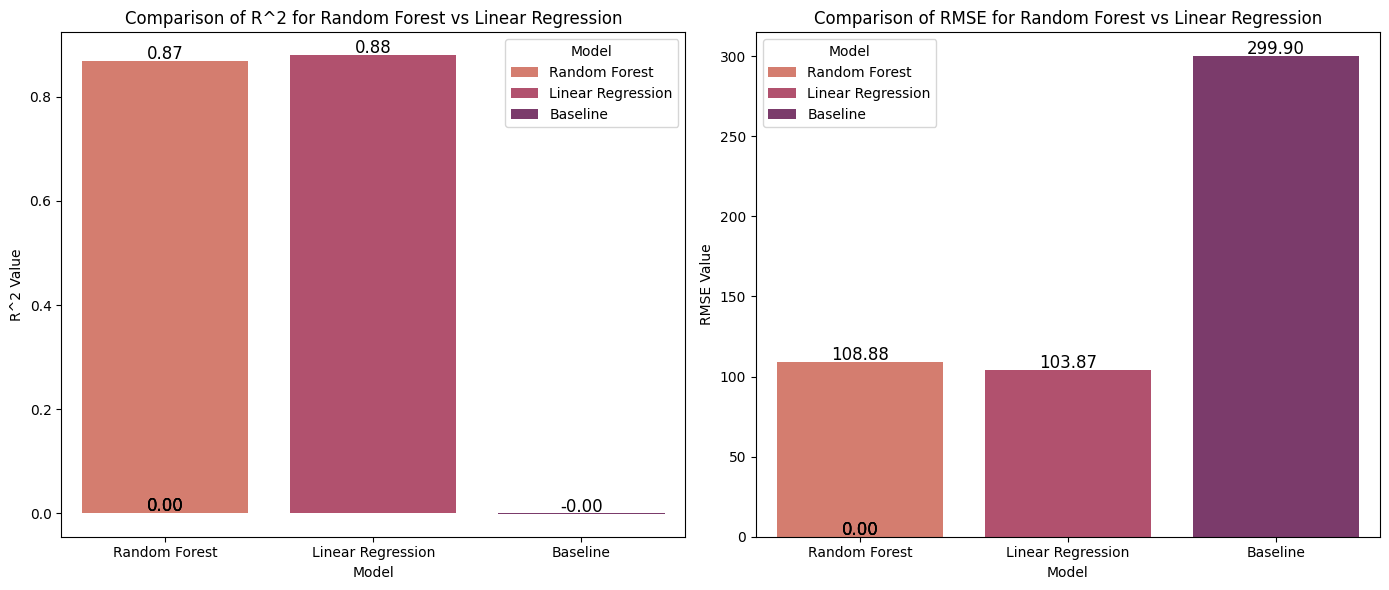

In [152]:
# Create a plot to compare R2 and RMSE values

# Data for plotting
data_r2 = {
    'Model': [ 'Random Forest', 'Linear Regression', 'Baseline'],
    'Value': [ r2_rf_test, r2_lr_test, r2_bl_test]
}
data_rmse = {
    'Model': ['Random Forest', 'Linear Regression', 'Baseline'],
    'Value': [rmse_rf_test, rmse_lr_test, rmse_bl_test]
}

r2_df = pd.DataFrame(data_r2)
rmse_df = pd.DataFrame(data_rmse)

# Create the figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for R^2 using the 'flare' palette
sns.barplot(data=r2_df, x='Model', y='Value', hue='Model', palette='flare', ax=axes[0], legend = True)
axes[0].set_title('Comparison of R^2 for Random Forest vs Linear Regression')
axes[0].set_ylabel('R^2 Value')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', 
                     fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')


# Plot for RMSE using the 'flare' palette
sns.barplot(data=rmse_df, x='Model', y='Value', hue='Model', palette='flare', ax=axes[1], legend = True)
axes[1].set_title('Comparison of RMSE for Random Forest vs Linear Regression')
axes[1].set_ylabel('RMSE Value')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', 
                     fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')


plt.tight_layout()
plt.show()

In [153]:
# Define folder
MODEL_FOLDER = Path("../../models/precipitation_fall")

# Download the processing pipelines
# Save cleaning pipeline
with open(MODEL_FOLDER / "cleaning_pipeline-experiment-2.pkl", "wb") as f:
    cloudpickle.dump(cleaning_pipeline, f)

# Save engineering pipeline
with open(MODEL_FOLDER / "eng_pipeline-experiment-2.pkl", "wb") as f:
    cloudpickle.dump(eng_pipeline, f)

# Save data transform pipeline
with open(MODEL_FOLDER / "data_transform_pipeline-experiment-2.pkl", "wb") as f:
    cloudpickle.dump(data_transform_pipeline, f)

In [154]:
# Save the best model
best_model = lr_search.best_estimator_
joblib.dump(best_model, '../../models/precipitation_fall/36120-25SP-AT2-25548684-experiment-2.joblib')

['../../models/precipitation_fall/36120-25SP-AT2-25548684-experiment-2.joblib']

In [155]:
# <Student to fill this section>
model_performance_explanations = """
Linear Regression demonstrated slightly better performance than Random Forest, with lower RMSE on validation (100.67) and test (103.87) and 
higher R² (0.876–0.880). Random Forest showed marginally higher RMSE, indicating slight underfitting on hourly precipitation data. Both models 
effectively captured temporal and meteorological trends, with Linear Regression providing more stable, interpretable predictions for three-day 
cumulative precipitation.
"""

In [156]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### K.5 Business Impact from Current Model Performance

> Precise three-day precipitation volume forecasts are crucial for hydropower management, water resource planning, and flood risk assessment. 
Underestimating rainfall could compromise water supply and risk mitigation strategies, while overestimation might trigger unnecessary 
operational adjustments. Linear Regression’s lower RMSE and higher R² ensures more dependable predictions, minimizing financial and operational 
losses, whereas Random Forest’s slightly higher errors could moderately affect decision-making accuracy.


In [157]:
# <Student to fill this section>
business_impacts_explanations = """
Precise three-day precipitation volume forecasts are crucial for hydropower management, water resource planning, and flood risk assessment. 
Underestimating rainfall could compromise water supply and risk mitigation strategies, while overestimation might trigger unnecessary 
operational adjustments. Linear Regression’s lower RMSE and higher R² ensures more dependable predictions, minimizing financial and operational 
losses, whereas Random Forest’s slightly higher errors could moderately affect decision-making accuracy.
"""

In [158]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## L. Project Outcomes

In [159]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Rejected - Linear models outperformed ensemble model" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [160]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [161]:
# <Student to fill this section>
experiment_results_explanations = """
Linear Regression achieved lower RMSE and higher R² than Random Forest, showing that hourly weather features predominantly follow linear trends 
when predicting precipitation totals. The hypothesis that ensembles outperform linear models is not strongly supported here. Further experiments 
could explore Gradient Boosting or hybrid models combining linear and non-linear components, with an expected moderate uplift in predictive accuracy. 
Feature engineering of derived variables like precipitation intensity or moving averages may also help. Linear Regression’s performance is sufficient 
for deployment, supporting API-based delivery while continuing experimentation to enhance prediction precision.
"""

In [162]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)